### IBL Prior and Stim coding in Stimulus Interval


- Regions 
    - animal 1
    - animal 2
    - ...
    - animal n
- Load data
  - collate all the arrays into one (all pairs, etc)
  - different conditions
  - these are corrected measures
  - should I compute the same for biased (yes, think so)
- Plot data
  - Violin plots

In [1]:
import numpy as np
import pickle as pkl
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from glob import glob

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
important_regions = [
    "VISp",
    "MOs",
    "SSp-ul",
    "ACAd",
    "PL",
    "CP",
    "VPM",
    "MG",
    "LGd",
    "ZI",
    "SNr",
    "MRN",
    "SCm",
    "PAG",
    "APN",
    "RN",
    "PPN",
    "PRNc",
    "PRNr",
    "GRN",
    "IRN",
    "PGRN",
    "CUL4 5",
    "SIM",
    "IP",
]

In [4]:
from ibl_info.stim_prior_results import compute_means_and_sems

In [5]:
region_pickles = glob("../data/generated/nofilter/equi/2bins/*.pkl")
region_names = np.asarray([r.rsplit("_stim")[-2].rsplit("_")[-1] for r in region_pickles])

In [6]:
from ibl_info.stim_prior_results import aggregate_all_data, aggregate_data

In [7]:
from scipy.stats import wilcoxon
from ibl_info.stim_prior_results import convert_to_markers, regional_pid_results

In [8]:
from tqdm import tqdm

flatmap_differences = np.zeros((len(region_names), 4))
for idx, pickle_location in tqdm(enumerate(region_pickles)):

    with open(pickle_location, "rb") as f:
        region_data = pkl.load(f)

    region_name = region_names[idx]
    # synergy_delta, redundancy_delta, rsi_congruent, rsi_incongruent = regional_pid_results(
    #     region_data, region_name, zero_out=False, congruent_id="subsampled"
    # )
    # _ = regional_pid_results(region_data, region_name, zero_out=False, congruent_id="congruent")
    try:
        _ = regional_pid_results(
            region_data, region_name, zero_out=False, congruent_id="subsampled"
        )
        # _ = regional_pid_results(
        #     region_data, region_name, zero_out=False, congruent_id="incongruent"
        # )
    except Exception as e:
        print("error in {region_name}")
    # _ = regional_pid_results(region_data, region_name, zero_out=True, congruent_id="subsampled")
    # _ = regional_pid_results(region_data, region_name, zero_out=True, congruent_id="incongruent")
    # flatmap_differences[idx, :] = synergy_delta, redundancy_delta, rsi_congruent, rsi_incongruent

25it [00:03,  8.20it/s]


In [8]:
A = regional_pid_results(region_pickles, "all", zero_out=False, congruent_id="subsampled")
# _ = regional_pid_results(region_pickles, "all", zero_out=True, congruent_id="subsampled")

In [10]:
A[0]

np.float64(2.4470205710720554e-05)

In [64]:
from ibl_info.swanson_plots import plot_vertical_swanson, plot_horizontal_swanson

/Users/kschille/micromamba/envs/info-decom/lib/python3.12/site-packages/iblatlas/regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x17bd277d0>)

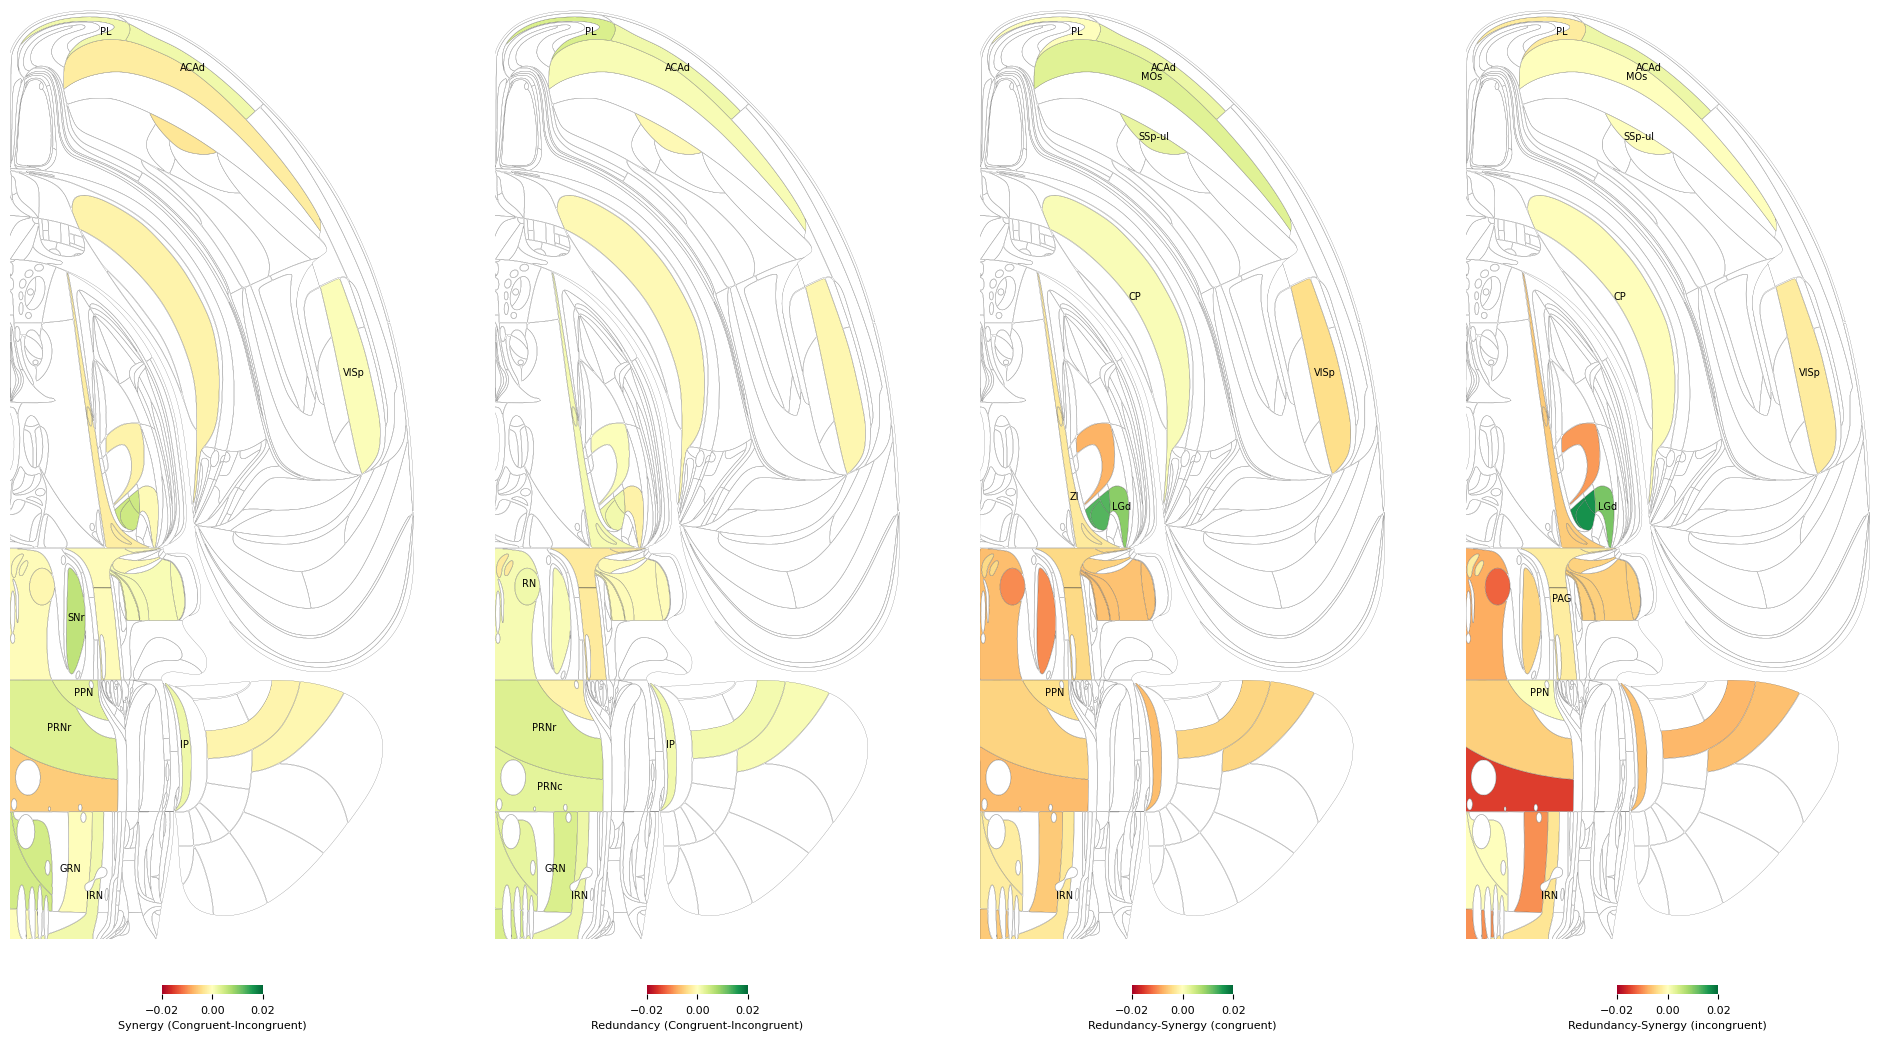

In [65]:
fig, ax = plt.subplots(figsize=(24, 24), ncols=4)
plot_vertical_swanson(
    region_names,
    flatmap_differences[:, 0],
    vmin=-0.02,
    vmax=0.02,
    annotate_kwargs={"annotate": True},
    legend=False,
    ax=ax[0],
    cbar_shrink=0.25,
    cbar_label="Synergy (Congruent-Incongruent)",
    cmap="RdYlGn",
)
plot_vertical_swanson(
    region_names,
    flatmap_differences[:, 1],
    vmin=-0.02,
    vmax=0.02,
    annotate_kwargs={"annotate": True},
    legend=False,
    ax=ax[1],
    cbar_shrink=0.25,
    cbar_label="Redundancy (Congruent-Incongruent)",
    cmap="RdYlGn",
)
plot_vertical_swanson(
    region_names,
    flatmap_differences[:, 2],
    vmin=-0.02,
    vmax=0.02,
    annotate_kwargs={"annotate": True},
    legend=False,
    ax=ax[2],
    cbar_shrink=0.25,
    cbar_label="Redundancy-Synergy (congruent)",
    cmap="RdYlGn",
)
plot_vertical_swanson(
    region_names,
    flatmap_differences[:, 3],
    vmin=-0.02,
    vmax=0.02,
    annotate_kwargs={"annotate": True},
    legend=False,
    ax=ax[3],
    cbar_shrink=0.25,
    cbar_label="Redundancy-Synergy (incongruent)",
    cmap="RdYlGn",
)

In [66]:
# spiking rate

In [67]:
from ibl_info.utils import FIRING_RATE

In [77]:
names = list(FIRING_RATE.keys())
values = np.asarray(list(FIRING_RATE.values()))

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x17d04d9a0>)

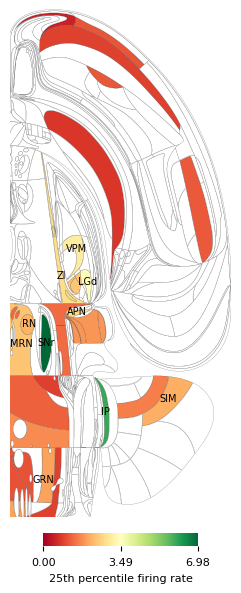

In [83]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_vertical_swanson(
    names,
    values,
    vmin=0,
    vmax=np.max(values),
    annotate_kwargs={"annotate": True},
    legend=False,
    cbar_shrink=0.25,
    cbar_label="25th percentile firing rate",
    cmap="RdYlGn",
    ax=ax,
)

array([1.2       , 0.9057971 , 1.15451576, 1.14014252, 0.51339195,
       0.7788162 , 3.08452968, 2.4375    , 3.46194153, 2.76673208,
       6.9827745 , 2.42424545, 1.82989691, 1.36950904, 2.7202381 ,
       2.19730942, 0.90007215, 1.72091216, 1.27516779, 1.97734925,
       0.90866472, 1.11009097, 1.6       , 2.13235294, 5.97949886])

In [39]:
scores

array([-1.07710449,  1.15804817, -0.58764389, -1.65335492,  0.26589493,
        1.8067583 , -1.22211828,  0.97929963,  1.32534969,  1.13106435,
       -1.83063776, -1.37013122, -0.1147779 ,  0.10453978, -0.4627177 ,
        1.39811515,  0.14645744,  0.97088882,  0.12372104,  0.8744631 ,
       -0.70661597, -0.26554921, -0.42898058,  0.41444918,  1.31069712])

In [22]:
# ideas?
# over general regions
# cortical hierarchy
# time windows or without time windows?
# window (Choice for choice, stimulus for stimulus, prior for prior (just go for raw block (maybe for now, idk)))
# write the decoder
# - what about validation.